In [5]:
# ── Setup & Imports ──
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

# ── Color Theme ──
TITLE  = '#6E5791'
VALUE  = '#980606'
LABEL  = '#6C6966'
BAR    = ['#118DFF','#12239E','#382258','#E66C37','#43A047']

plt.rcParams.update({
    'font.size': 13, 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold',
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.facecolor': '#000000', 'axes.facecolor': '#000000',
    'axes.edgecolor': LABEL, 'axes.labelcolor': LABEL,
    'xtick.color': VALUE, 'ytick.color': VALUE,
    'text.color': LABEL, 'axes.titlecolor': TITLE,
    'axes.grid': False,
})

print('✅ Libraries loaded')

✅ Libraries loaded


In [6]:
# ── Load Data & Create SQLite DB ──
df = pd.read_csv('/kaggle/input/datasets/kvsherlin/sample/Sample - Superstore.csv',
                 encoding='latin-1',
                 parse_dates=['Order Date','Ship Date'])

# Clean column names
df.columns = [c.strip().replace(' ','_').replace('-','_') for c in df.columns]
df['Order_Date']    = pd.to_datetime(df['Order_Date'])
df['Ship_Date']     = pd.to_datetime(df['Ship_Date'])
df['Order_Year']    = df['Order_Date'].dt.year
df['Order_Month']   = df['Order_Date'].dt.month
df['Order_Quarter'] = df['Order_Date'].dt.quarter
df['Days_to_Ship']  = (df['Ship_Date'] - df['Order_Date']).dt.days

# SQLite in-memory
conn = sqlite3.connect(':memory:')
df.to_sql('superstore', conn, index=False, if_exists='replace')

print(f'✅ SQLite database ready')
print(f'   Rows    : {len(df):,}')
print(f'   Columns : {len(df.columns)}')

def run_query(sql, title=''):
    result = pd.read_sql(sql, conn)
    if title:
        print(f"\n{'━'*65}")
        print(f'  📊 {title}')
        print(f"{'━'*65}")
        print(result.to_string(index=False))
        print(f"{'━'*65}")
    return result

print('✅ run_query() helper ready')

✅ SQLite database ready
   Rows    : 9,994
   Columns : 25
✅ run_query() helper ready


In [7]:
# ── Q1: Overall Business KPIs ──
run_query("""
    SELECT
        COUNT(DISTINCT Order_ID)               AS total_orders,
        COUNT(DISTINCT Customer_ID)            AS total_customers,
        COUNT(DISTINCT Product_ID)             AS total_products,
        ROUND(SUM(Sales), 0)                   AS total_revenue,
        ROUND(SUM(Profit), 0)                  AS total_profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 2)   AS profit_margin_pct,
        ROUND(AVG(Sales), 2)                   AS avg_order_value,
        ROUND(AVG(Discount)*100, 1)            AS avg_discount_pct
    FROM superstore
""", "OVERALL BUSINESS KPIs")
# ── Q2: Revenue & Profit by Category ──
run_query("""
    SELECT
        Category,
        COUNT(*)                               AS orders,
        ROUND(SUM(Sales), 0)                   AS revenue,
        ROUND(SUM(Profit), 0)                  AS profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 2)   AS margin_pct,
        ROUND(AVG(Discount)*100, 1)            AS avg_discount_pct
    FROM superstore
    GROUP BY Category
    ORDER BY revenue DESC
""", "REVENUE & PROFIT BY CATEGORY")
# ── Q3: Loss-Making Sub-Categories ──
run_query("""
    SELECT
        Sub_Category, Category,
        COUNT(*)                               AS orders,
        ROUND(SUM(Sales), 0)                   AS revenue,
        ROUND(SUM(Profit), 0)                  AS profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 2)   AS margin_pct,
        ROUND(AVG(Discount)*100, 1)            AS avg_discount_pct
    FROM superstore
    GROUP BY Sub_Category, Category
    HAVING SUM(Profit) < 0
    ORDER BY profit ASC
""", "⚠️  LOSS-MAKING SUB-CATEGORIES")
# ── Q4: Discount Impact on Profit (CASE WHEN + CTE) ──
run_query("""
    WITH disc_buckets AS (
        SELECT *,
            CASE
                WHEN Discount = 0         THEN '0%  No Discount'
                WHEN Discount <= 0.10     THEN '1-10%'
                WHEN Discount <= 0.20     THEN '11-20%'
                WHEN Discount <= 0.30     THEN '21-30%'
                WHEN Discount <= 0.50     THEN '31-50%'
                ELSE                           '50%+ Heavy'
            END AS discount_band
        FROM superstore
    )
    SELECT
        discount_band,
        COUNT(*)                               AS orders,
        ROUND(AVG(Sales), 2)                   AS avg_sales,
        ROUND(AVG(Profit), 2)                  AS avg_profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 2)   AS margin_pct
    FROM disc_buckets
    GROUP BY discount_band
    ORDER BY AVG(Discount)
""", "💸 DISCOUNT IMPACT ON PROFIT MARGIN")
# ── Q5: Monthly Revenue + MoM Growth (CTE + LAG) ──
run_query("""
    WITH monthly AS (
        SELECT Order_Year AS year, Order_Month AS month,
               ROUND(SUM(Sales), 0)  AS revenue,
               ROUND(SUM(Profit), 0) AS profit
        FROM superstore
        GROUP BY Order_Year, Order_Month
    ),
    with_growth AS (
        SELECT *,
            LAG(revenue) OVER (ORDER BY year, month) AS prev_revenue,
            ROUND((revenue - LAG(revenue) OVER (ORDER BY year, month))
                  * 100.0 / NULLIF(LAG(revenue) OVER (ORDER BY year, month), 0), 2)
                  AS mom_growth_pct
        FROM monthly
    )
    SELECT year, month, revenue, profit,
           COALESCE(mom_growth_pct, 0) AS mom_growth_pct
    FROM with_growth
    ORDER BY year, month
""", "MONTHLY REVENUE + MoM GROWTH (CTE + LAG)")
# ── Q6: RFM Segmentation (NTILE + 3-Level CTE) ──
run_query("""
    WITH rfm AS (
        SELECT Customer_ID, Customer_Name, Segment,
               MAX(Order_Date)            AS last_order,
               COUNT(DISTINCT Order_ID)   AS frequency,
               ROUND(SUM(Sales), 0)       AS monetary
        FROM superstore GROUP BY Customer_ID, Customer_Name, Segment
    ),
    scored AS (
        SELECT *,
            NTILE(5) OVER (ORDER BY last_order DESC) AS recency_score,
            NTILE(5) OVER (ORDER BY frequency DESC)  AS frequency_score,
            NTILE(5) OVER (ORDER BY monetary DESC)   AS monetary_score
        FROM rfm
    ),
    segmented AS (
        SELECT *,
            CASE
                WHEN recency_score  >= 4
                 AND frequency_score>= 4
                 AND monetary_score >= 4  THEN '🏆 Champions'
                WHEN recency_score  >= 3
                 AND frequency_score>= 3  THEN '⭐ Loyal'
                WHEN recency_score  >= 4  THEN '🆕 Recent'
                WHEN monetary_score >= 4  THEN '💰 Big Spenders'
                WHEN recency_score  <= 2
                 AND frequency_score<= 2  THEN '😴 At Risk'
                ELSE                           '📦 Regular'
            END AS rfm_segment
        FROM scored
    )
    SELECT rfm_segment,
           COUNT(*) AS customers,
           ROUND(AVG(monetary), 0) AS avg_revenue,
           ROUND(AVG(frequency), 1) AS avg_orders
    FROM segmented
    GROUP BY rfm_segment
    ORDER BY avg_revenue DESC
""", "RFM CUSTOMER SEGMENTATION")
# ── Q7: YoY Growth by Category (LAG + LEAD + PARTITION BY) ──
run_query("""
    WITH yearly_cat AS (
        SELECT Order_Year AS year, Category,
               ROUND(SUM(Sales), 0)  AS revenue,
               ROUND(SUM(Profit), 0) AS profit
        FROM superstore
        GROUP BY Order_Year, Category
    )
    SELECT *,
        LAG(revenue) OVER (PARTITION BY Category ORDER BY year)  AS prev_year_revenue,
        ROUND((revenue - LAG(revenue) OVER (PARTITION BY Category ORDER BY year))
              * 100.0 / NULLIF(LAG(revenue) OVER (PARTITION BY Category ORDER BY year), 0), 2)
              AS yoy_growth_pct
    FROM yearly_cat
    ORDER BY Category, year
""", "YoY GROWTH BY CATEGORY (LAG + PARTITION BY)")
# ── Q8: Top & Bottom States by Profit (RANK + Subquery) ──
run_query("""
    WITH state_perf AS (
        SELECT State, Region,
               ROUND(SUM(Sales), 0)  AS revenue,
               ROUND(SUM(Profit), 0) AS profit,
               ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS margin_pct,
               RANK() OVER (ORDER BY SUM(Profit) DESC) AS profit_rank
        FROM superstore GROUP BY State, Region
    )
    SELECT * FROM state_perf
    WHERE profit_rank <= 5
       OR profit_rank > (SELECT COUNT(DISTINCT State) FROM superstore) - 5
    ORDER BY profit DESC
""", "TOP & BOTTOM 5 STATES BY PROFIT")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 OVERALL BUSINESS KPIs
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 total_orders  total_customers  total_products  total_revenue  total_profit  profit_margin_pct  avg_order_value  avg_discount_pct
         5009              793            1862      2297201.0      286397.0              12.47           229.86              15.6
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 REVENUE & PROFIT BY CATEGORY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       Category  orders  revenue   profit  margin_pct  avg_discount_pct
     Technology    1847 836154.0 145455.0       17.40              13.2
      Furniture    2121 742000.0  18451.0        2.49              17.4
Office Supplies    6026 719047.0 122491.0       17.04              15.7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

,State,Region,revenue,profit,margin_pct,profit_rank
0,California,West,457688.0,76381.0,16.69,1
1,New York,East,310876.0,74039.0,23.82,2
2,Washington,West,138641.0,33403.0,24.09,3
3,Michigan,Central,76270.0,24463.0,32.07,4
4,Virginia,South,70637.0,18598.0,26.33,5
5,North Carolina,South,55603.0,-7491.0,-13.47,45
6,Illinois,Central,80166.0,-12608.0,-15.73,46
7,Pennsylvania,East,116512.0,-15560.0,-13.35,47
8,Ohio,East,78258.0,-16971.0,-21.69,48
9,Texas,Central,170188.0,-25729.0,-15.12,49


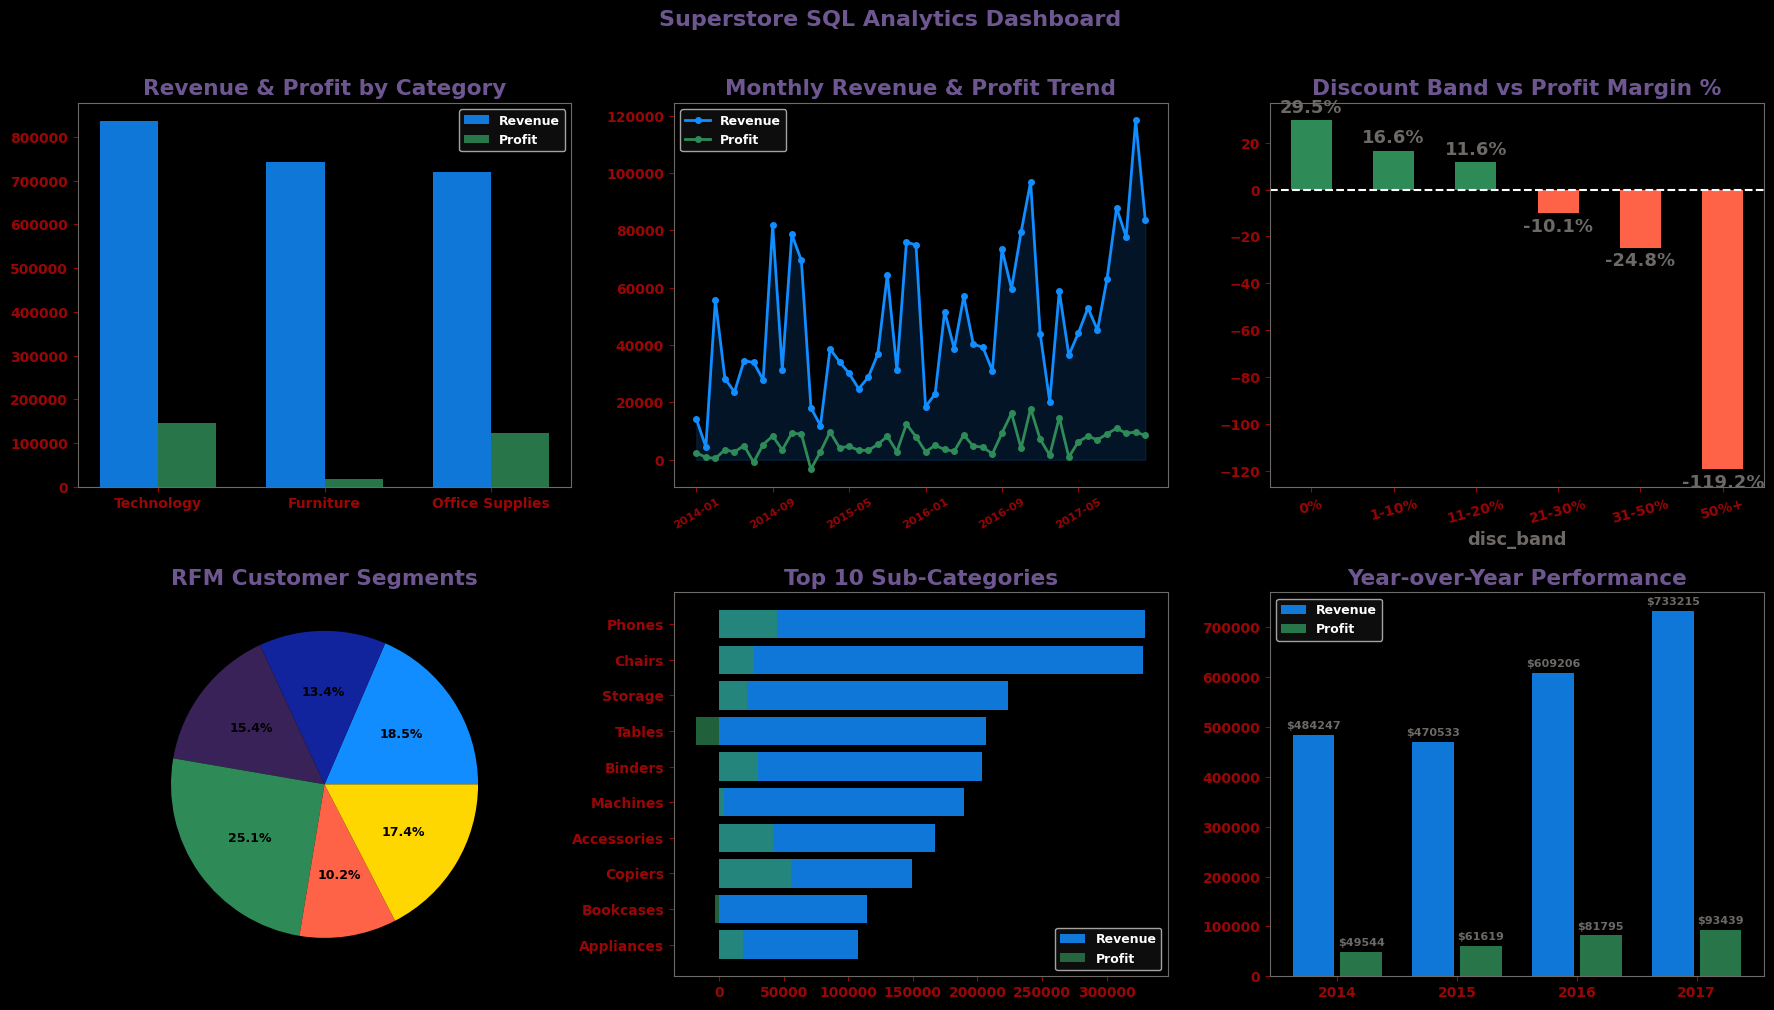

In [8]:
# ── SQL Analytics Dashboard (6 Charts) ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Chart 1: Revenue & Profit by Category
cat = run_query("""
    SELECT Category, ROUND(SUM(Sales),0) AS revenue, ROUND(SUM(Profit),0) AS profit
    FROM superstore GROUP BY Category ORDER BY revenue DESC
""")
x = np.arange(len(cat))
width = 0.35
axes[0,0].bar(x-width/2, cat['revenue'], width, color='#118DFF', label='Revenue', alpha=0.85)
axes[0,0].bar(x+width/2, cat['profit'],  width, color='seagreen', label='Profit', alpha=0.85)
axes[0,0].set_title('Revenue & Profit by Category')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(cat['Category'])
axes[0,0].legend(facecolor='#111111', labelcolor='white', fontsize=9)

# Chart 2: Monthly Revenue Trend
monthly = run_query("""
    SELECT Order_Year||'-'||printf('%02d',Order_Month) AS month,
           ROUND(SUM(Sales),0) AS revenue, ROUND(SUM(Profit),0) AS profit
    FROM superstore GROUP BY Order_Year, Order_Month ORDER BY Order_Year, Order_Month
""")
axes[0,1].plot(range(len(monthly)), monthly['revenue'], 'o-', color='#118DFF', linewidth=2, markersize=4, label='Revenue')
axes[0,1].plot(range(len(monthly)), monthly['profit'],  'o-', color='seagreen', linewidth=2, markersize=4, label='Profit')
axes[0,1].fill_between(range(len(monthly)), monthly['revenue'], alpha=0.15, color='#118DFF')
axes[0,1].set_title('Monthly Revenue & Profit Trend')
step = max(1, len(monthly)//6)
axes[0,1].set_xticks(range(0, len(monthly), step))
axes[0,1].set_xticklabels(monthly['month'].iloc[::step], rotation=30, fontsize=8)
axes[0,1].legend(facecolor='#111111', labelcolor='white', fontsize=9)

# Chart 3: Discount Band vs Margin
disc = run_query("""
    SELECT CASE WHEN Discount=0 THEN '0%' WHEN Discount<=0.1 THEN '1-10%'
                WHEN Discount<=0.2 THEN '11-20%' WHEN Discount<=0.3 THEN '21-30%'
                WHEN Discount<=0.5 THEN '31-50%' ELSE '50%+' END AS disc_band,
           ROUND(SUM(Profit)/SUM(Sales)*100,2) AS margin_pct, COUNT(*) AS orders
    FROM superstore GROUP BY disc_band ORDER BY AVG(Discount)
""")
colors_d = ['seagreen' if m > 0 else 'tomato' for m in disc['margin_pct']]
disc.plot(kind='bar', x='disc_band', y='margin_pct', ax=axes[0,2], color=colors_d, width=0.5, legend=False)
axes[0,2].set_title('Discount Band vs Profit Margin %')
axes[0,2].axhline(y=0, color='white', linestyle='--', linewidth=1.5)
axes[0,2].tick_params(axis='x', rotation=15)
for container in axes[0,2].containers:
    axes[0,2].bar_label(container, fmt='%.1f%%', padding=3, color=LABEL, fontweight='bold')

# Chart 4: RFM Segments
rfm = run_query("""
    WITH rfm AS (
        SELECT Customer_ID, MAX(Order_Date) AS last_order,
               COUNT(DISTINCT Order_ID) AS freq, SUM(Sales) AS mon
        FROM superstore GROUP BY Customer_ID
    ), s AS (
        SELECT *, NTILE(5) OVER (ORDER BY last_order DESC) AS R,
               NTILE(5) OVER (ORDER BY freq DESC) AS F,
               NTILE(5) OVER (ORDER BY mon DESC)  AS M
        FROM rfm
    )
    SELECT CASE WHEN R>=4 AND F>=4 AND M>=4 THEN 'Champions'
                WHEN R>=3 AND F>=3          THEN 'Loyal'
                WHEN R>=4                   THEN 'Recent'
                WHEN M>=4                   THEN 'Big Spenders'
                WHEN R<=2 AND F<=2          THEN 'At Risk'
                ELSE 'Regular' END AS segment, COUNT(*) AS customers
    FROM s GROUP BY segment
""")
rfm.plot(kind='pie', y='customers', labels=rfm['segment'], ax=axes[1,0],
         autopct='%1.1f%%', colors=['#118DFF','#12239E','#382258','seagreen','tomato','#FFD700'],
         textprops={'color':'black','fontsize':9}, legend=False)
axes[1,0].set_title('RFM Customer Segments')
axes[1,0].set_ylabel('')

# Chart 5: Top 10 Sub-Categories
subcat = run_query("""
    SELECT Sub_Category, ROUND(SUM(Sales),0) AS revenue, ROUND(SUM(Profit),0) AS profit
    FROM superstore GROUP BY Sub_Category ORDER BY revenue DESC LIMIT 10
""")
subcat_s = subcat.sort_values('revenue')
axes[1,1].barh(subcat_s['Sub_Category'], subcat_s['revenue'], color='#118DFF', alpha=0.85, label='Revenue')
axes[1,1].barh(subcat_s['Sub_Category'], subcat_s['profit'],  color='seagreen', alpha=0.7,  label='Profit')
axes[1,1].set_title('Top 10 Sub-Categories')
axes[1,1].legend(facecolor='#111111', labelcolor='white', fontsize=9)

# Chart 6: YoY Performance
yoy = run_query("""
    SELECT Order_Year, ROUND(SUM(Sales),0) AS revenue, ROUND(SUM(Profit),0) AS profit
    FROM superstore GROUP BY Order_Year ORDER BY Order_Year
""")
x2 = np.arange(len(yoy))
axes[1,2].bar(x2-0.2, yoy['revenue'], 0.35, color='#118DFF', label='Revenue', alpha=0.85)
axes[1,2].bar(x2+0.2, yoy['profit'],  0.35, color='seagreen', label='Profit',  alpha=0.85)
axes[1,2].set_title('Year-over-Year Performance')
axes[1,2].set_xticks(x2)
axes[1,2].set_xticklabels(yoy['Order_Year'].astype(str))
axes[1,2].legend(facecolor='#111111', labelcolor='white', fontsize=9)
for bars in axes[1,2].containers:
    axes[1,2].bar_label(bars, fmt='$%.0f', padding=3, color=LABEL, fontsize=8)

plt.suptitle('Superstore SQL Analytics Dashboard', color=TITLE, fontweight='bold', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# ── Load Data ──
df = pd.read_csv('/kaggle/input/datasets/kvsherlin/sample/Sample - Superstore.csv',
                 encoding='latin-1',
                 parse_dates=['Order Date', 'Ship Date'])

df.columns = [c.strip().replace(' ', '_').replace('-', '_') for c in df.columns]
df['Order_Date']    = pd.to_datetime(df['Order_Date'])
df['Ship_Date']     = pd.to_datetime(df['Ship_Date'])
df['Order_Year']    = df['Order_Date'].dt.year
df['Order_Month']   = df['Order_Date'].dt.month
df['Order_Quarter'] = df['Order_Date'].dt.quarter
df['Days_to_Ship']  = (df['Ship_Date'] - df['Order_Date']).dt.days

print(f'✅ Loaded: {len(df):,} rows × {len(df.columns)} cols')

✅ Loaded: 9,994 rows × 25 cols


In [10]:
# ── Feature Engineering ──
df_ml = df.copy()

# Interaction features
df_ml['Discount_x_Quantity'] = df_ml['Discount'] * df_ml['Quantity']
df_ml['High_Discount']       = (df_ml['Discount'] > 0.2).astype(int)
df_ml['Is_Q4']               = (df_ml['Order_Quarter'] == 4).astype(int)

# Encode categoricals
le = LabelEncoder()
cat_cols = ['Category', 'Sub_Category', 'Region', 'Segment', 'Ship_Mode']
for col in cat_cols:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])

feature_cols = [
    'Quantity',
    'Discount',
    'Discount_x_Quantity',   # bulk discount abuse
    'High_Discount',         # binary: >20% discount flag
    'Days_to_Ship',
    'Category_enc',
    'Sub_Category_enc',      # key: Tables/Bookcases = loss
    'Region_enc',
    'Segment_enc',
    'Ship_Mode_enc',
    'Order_Month',
    'Order_Quarter',
    'Is_Q4',
    'Order_Year',
]

# Target: Profit Margin % (more stable than raw profit)
df_ml['Profit_Margin'] = df_ml['Profit'] / df_ml['Sales']

# Remove extreme outliers
mask = df_ml['Profit_Margin'].between(-2.0, 1.0)
df_clean = df_ml[mask].copy()

X = df_clean[feature_cols]
y = df_clean['Profit_Margin']

print(f'Rows after cleaning : {len(X):,}')
print(f'Target mean margin  : {y.mean()*100:.1f}%')
print(f'Target range        : {y.min()*100:.1f}% to {y.max()*100:.1f}%')

Rows after cleaning : 9,928
Target mean margin  : 13.8%
Target range        : -180.0% to 50.0%


In [11]:
# ── Correlation with Target ──
corr = df_clean[feature_cols + ['Profit_Margin']].corr()['Profit_Margin'].drop('Profit_Margin')
corr = corr.sort_values(key=abs, ascending=False)
print("\nFeature Correlations with Profit Margin:")
print(f"  {'Feature':<25} {'Correlation':>12}")
print("  " + "─"*40)
for feat, val in corr.items():
    bar = '█' * int(abs(val) * 40)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:<25} {sign}{abs(val):.4f}  {bar}")


Feature Correlations with Profit Margin:
  Feature                    Correlation
  ────────────────────────────────────────
  Discount                  -0.8727  ██████████████████████████████████
  High_Discount             -0.7922  ███████████████████████████████
  Discount_x_Quantity       -0.7161  ████████████████████████████
  Region_enc                +0.2018  ████████
  Sub_Category_enc          +0.1063  ████
  Category_enc              +0.0923  ███
  Segment_enc               +0.0169  
  Days_to_Ship              -0.0130  
  Quantity                  -0.0109  
  Order_Month               +0.0065  
  Is_Q4                     -0.0054  
  Ship_Mode_enc             -0.0041  
  Order_Year                +0.0037  
  Order_Quarter             +0.0015  


In [12]:
# ── Train / Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 7,942 | Test: 1,986


In [13]:
# ── Train All 4 Models ──
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=10.0),
    'Random Forest'     : RandomForestRegressor(
                            n_estimators=300,
                            max_depth=12,
                            min_samples_leaf=3,
                            max_features='sqrt',
                            random_state=42,
                            n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(
                            n_estimators=500,
                            learning_rate=0.03,
                            max_depth=5,
                            min_samples_leaf=3,
                            subsample=0.8,
                            max_features='sqrt',
                            random_state=42),
}

results = {}
for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f'  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')

print('\n✅ All models trained!')


Training Linear Regression...
  R²=0.7909  RMSE=0.1990  MAE=0.1517

Training Ridge Regression...
  R²=0.7892  RMSE=0.1998  MAE=0.1518

Training Random Forest...
  R²=0.9369  RMSE=0.1094  MAE=0.0770

Training Gradient Boosting...
  R²=0.9436  RMSE=0.1033  MAE=0.0690

✅ All models trained!


In [14]:
# ── Model Comparison ──
print(f"\n{'Model':<22} {'R²':>8} {'RMSE':>10} {'MAE':>10} {'Verdict'}")
print("─"*65)

best_model_name = max(results, key=lambda k: results[k]['R2'])
for name, res in results.items():
    flag = '🏆 BEST' if name == best_model_name else ''
    print(f"{name:<22} {res['R2']:>8.4f} {res['RMSE']:>10.4f} {res['MAE']:>10.4f}  {flag}")


Model                        R²       RMSE        MAE Verdict
─────────────────────────────────────────────────────────────────
Linear Regression        0.7909     0.1990     0.1517  
Ridge Regression         0.7892     0.1998     0.1518  
Random Forest            0.9369     0.1094     0.0770  
Gradient Boosting        0.9436     0.1033     0.0690  🏆 BEST


In [15]:
# ── Cross-Validation ──
best_model = results[best_model_name]['model']
cv_scores  = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print(f'\nBest Model    : {best_model_name}')
print(f'CV R² Scores  : {[f"{s:.4f}" for s in cv_scores]}')
print(f'CV Mean R²    : {cv_scores.mean():.4f}')
print(f'CV Std Dev    : {cv_scores.std():.4f}')
print(f'Stability     : {"✅ Stable" if cv_scores.std() < 0.05 else "⚠️  Some variance"}')


Best Model    : Gradient Boosting
CV R² Scores  : ['0.9448', '0.9386', '0.9442', '0.9352', '0.9442']
CV Mean R²    : 0.9414
CV Std Dev    : 0.0038
Stability     : ✅ Stable


In [16]:
# ── Feature Importance ──
for model_name in ['Random Forest', 'Gradient Boosting']:
    fi = pd.Series(
        results[model_name]['model'].feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

    print(f'\n{model_name} — Feature Importance:')
    print(f"  {'Feature':<25} {'Importance':>12}  Bar")
    print("  " + "─"*55)
    for feat, imp in fi.items():
        bar = '█' * int(imp * 60)
        print(f"  {feat:<25} {imp:>12.4f}  {bar}")


Random Forest — Feature Importance:
  Feature                     Importance  Bar
  ───────────────────────────────────────────────────────
  Discount                        0.4286  █████████████████████████
  High_Discount                   0.2282  █████████████
  Discount_x_Quantity             0.1616  █████████
  Sub_Category_enc                0.0884  █████
  Region_enc                      0.0318  █
  Category_enc                    0.0311  █
  Quantity                        0.0111  
  Order_Month                     0.0045  
  Days_to_Ship                    0.0044  
  Order_Year                      0.0033  
  Segment_enc                     0.0023  
  Ship_Mode_enc                   0.0022  
  Order_Quarter                   0.0019  
  Is_Q4                           0.0008  

Gradient Boosting — Feature Importance:
  Feature                     Importance  Bar
  ───────────────────────────────────────────────────────
  Discount                        0.4189  ████████████████

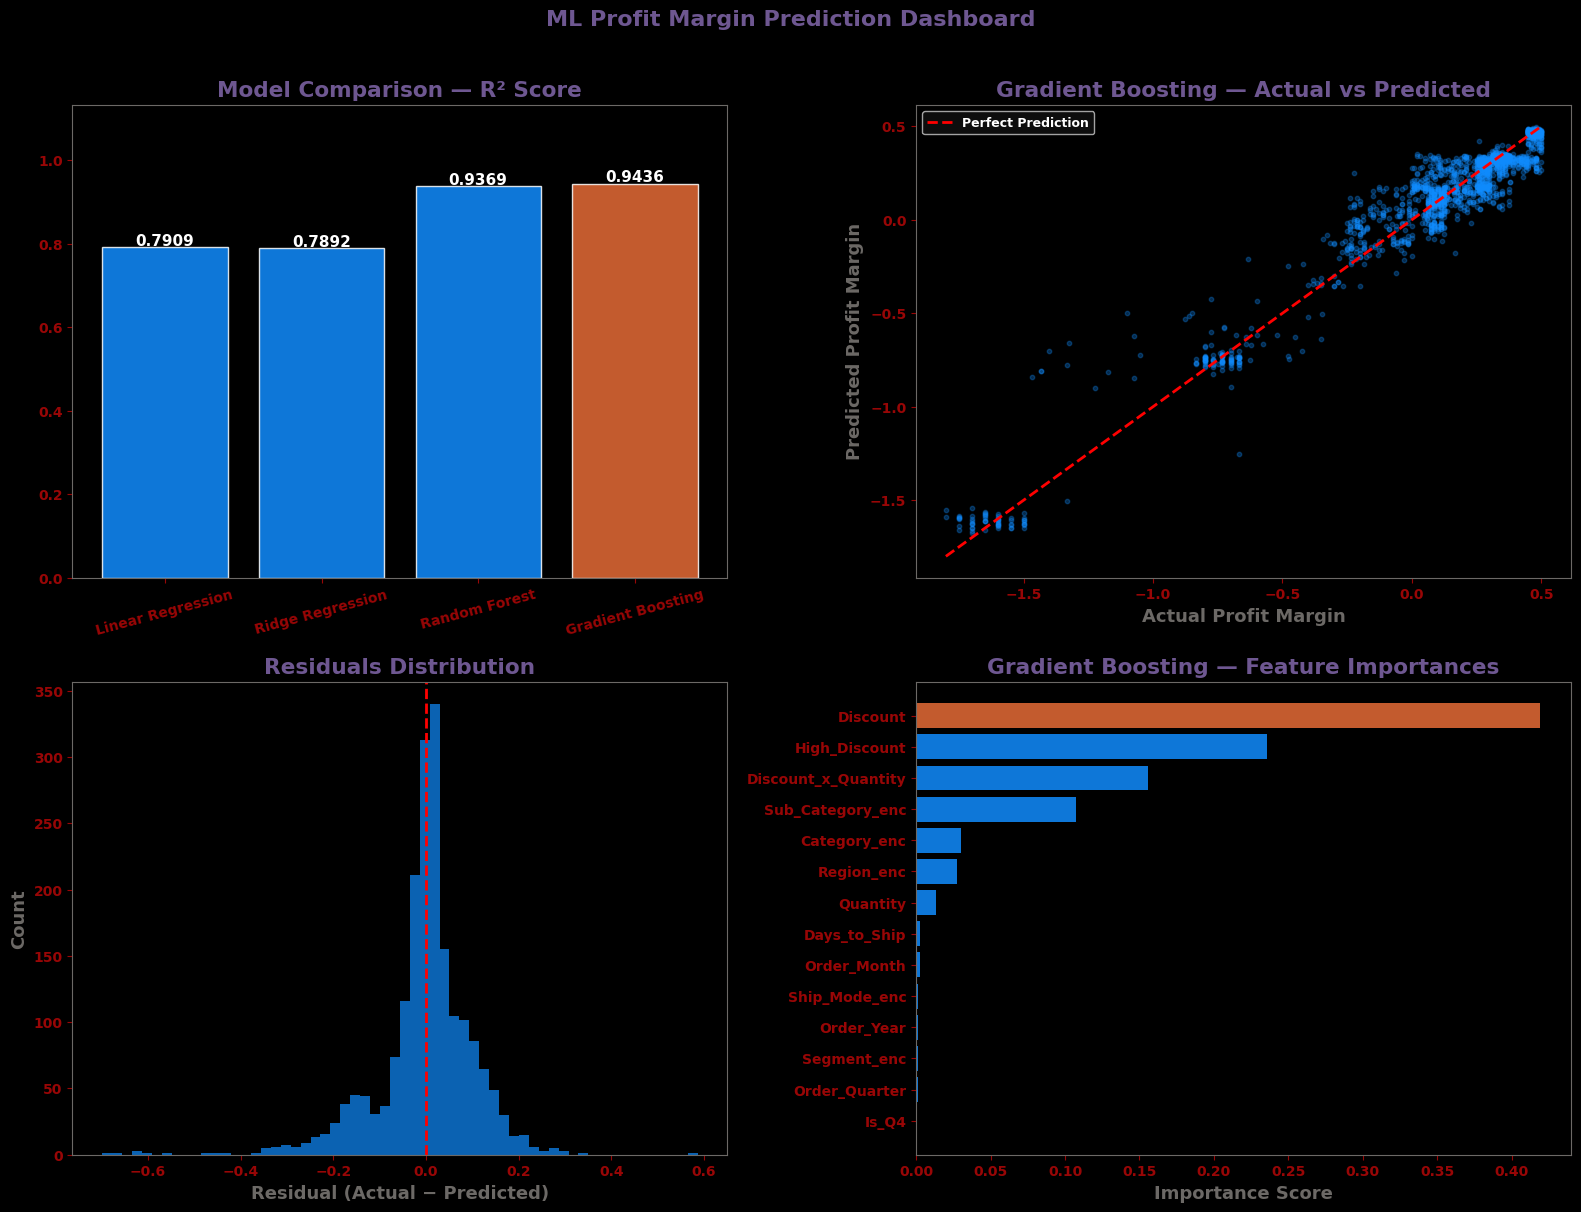

In [17]:
# ── Visualization Dashboard ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#000000')

TITLE = '#6E5791'
plt.rcParams.update({
    'axes.facecolor': '#000000', 'axes.edgecolor': '#6C6966',
    'text.color': '#6C6966', 'axes.titlecolor': '#6E5791',
    'xtick.color': '#980606', 'ytick.color': '#980606',
    'axes.labelcolor': '#6C6966',
})

# Chart 1: Model R² Comparison
model_names = list(results.keys())
r2_scores   = [results[m]['R2'] for m in model_names]
colors_m    = ['#E66C37' if m == best_model_name else '#118DFF' for m in model_names]
bars = axes[0,0].bar(model_names, r2_scores, color=colors_m, alpha=0.85, edgecolor='white')
axes[0,0].set_title('Model Comparison — R² Score')
axes[0,0].set_ylim(0, max(r2_scores) * 1.2)
axes[0,0].tick_params(axis='x', rotation=15)
for bar, score in zip(bars, r2_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.005,
                   f'{score:.4f}', ha='center',
                   fontsize=11, color='white', fontweight='bold')

# Chart 2: Actual vs Predicted
y_pred_best = results[best_model_name]['y_pred']
axes[0,1].scatter(y_test, y_pred_best, alpha=0.3, color='#118DFF', s=10)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0,1].plot([min_val, max_val], [min_val, max_val],
               'r--', linewidth=2, label='Perfect Prediction')
axes[0,1].set_title(f'{best_model_name} — Actual vs Predicted')
axes[0,1].set_xlabel('Actual Profit Margin')
axes[0,1].set_ylabel('Predicted Profit Margin')
axes[0,1].legend(facecolor='#111111', labelcolor='white', fontsize=9)

# Chart 3: Residuals Distribution
residuals = y_test - y_pred_best
axes[1,0].hist(residuals, bins=60, color='#118DFF', alpha=0.7)
axes[1,0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_title('Residuals Distribution')
axes[1,0].set_xlabel('Residual (Actual − Predicted)')
axes[1,0].set_ylabel('Count')

# Chart 4: Feature Importance
best_tree = 'Gradient Boosting' if results['Gradient Boosting']['R2'] >= results['Random Forest']['R2'] else 'Random Forest'
fi = pd.Series(results[best_tree]['model'].feature_importances_, index=feature_cols)
fi = fi.sort_values(ascending=True)
colors_fi = ['#E66C37' if f == fi.idxmax() else '#118DFF' for f in fi.index]
axes[1,1].barh(fi.index, fi.values, color=colors_fi, alpha=0.85)
axes[1,1].set_title(f'{best_tree} — Feature Importances')
axes[1,1].set_xlabel('Importance Score')

plt.suptitle('ML Profit Margin Prediction Dashboard',
             color=TITLE, fontweight='bold', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# ── Final Insights ──
best_r2  = results[best_model_name]['R2']
fi_top3  = pd.Series(results[best_tree]['model'].feature_importances_,
                     index=feature_cols).sort_values(ascending=False).head(3)

print(f"""
BEST MODEL     : {best_model_name}
R² Score       : {best_r2:.4f}  →  explains {best_r2*100:.1f}% of profit margin variance
RMSE           : {results[best_model_name]['RMSE']:.4f}

TOP 3 FEATURES :
  1. {fi_top3.index[0]:<25} {fi_top3.iloc[0]:.4f}
  2. {fi_top3.index[1]:<25} {fi_top3.iloc[1]:.4f}
  3. {fi_top3.index[2]:<25} {fi_top3.iloc[2]:.4f}

SQL → ML VALIDATION:
  ✅ SQL: discounts >30% destroy profit
     ML:  'Discount' / 'High_Discount' = top features

  ✅ SQL: Tables & Bookcases = loss-making
     ML:  'Sub_Category_enc' = significant predictor

  ✅ SQL: Technology = best margin
     ML:  'Category_enc' contributes to prediction
""")


BEST MODEL     : Gradient Boosting
R² Score       : 0.9436  →  explains 94.4% of profit margin variance
RMSE           : 0.1033

TOP 3 FEATURES :
  1. Discount                  0.4189
  2. High_Discount             0.2358
  3. Discount_x_Quantity       0.1558

SQL → ML VALIDATION:
  ✅ SQL: discounts >30% destroy profit
     ML:  'Discount' / 'High_Discount' = top features

  ✅ SQL: Tables & Bookcases = loss-making
     ML:  'Sub_Category_enc' = significant predictor

  ✅ SQL: Technology = best margin
     ML:  'Category_enc' contributes to prediction



In [19]:
# ── Interactive Profit Margin Predictor ──

# Get encoded values mapping
category_map     = {v: i for i, v in enumerate(sorted(df['Category'].unique()))}
sub_category_map = {v: i for i, v in enumerate(sorted(df['Sub_Category'].unique()))}
region_map       = {v: i for i, v in enumerate(sorted(df['Region'].unique()))}
segment_map      = {v: i for i, v in enumerate(sorted(df['Segment'].unique()))}
ship_mode_map    = {v: i for i, v in enumerate(sorted(df['Ship_Mode'].unique()))}

print("━"*55)
print("  🛒 SUPERSTORE PROFIT MARGIN PREDICTOR")
print("━"*55)

while True:
    print("\nEnter order details (or type 'quit' to exit)\n")

    # ── Inputs ──
    print(f"Category options     : {list(category_map.keys())}")
    category = input("Category             : ").strip()
    if category.lower() == 'quit':
        print("Exiting predictor. Goodbye! 👋")
        break

    print(f"\nSub-Category options : {list(sub_category_map.keys())}")
    sub_category = input("Sub-Category         : ").strip()

    print(f"\nRegion options       : {list(region_map.keys())}")
    region = input("Region               : ").strip()

    print(f"\nSegment options      : {list(segment_map.keys())}")
    segment = input("Segment              : ").strip()

    print(f"\nShip Mode options    : {list(ship_mode_map.keys())}")
    ship_mode = input("Ship Mode            : ").strip()

    quantity    = float(input("\nQuantity             : "))
    discount    = float(input("Discount (0.0–0.8)   : "))
    days_ship   = float(input("Days to Ship         : "))
    order_month = int(input("Order Month (1–12)   : "))

    # ── Derived features ──
    order_quarter       = (order_month - 1) // 3 + 1
    discount_x_quantity = discount * quantity
    high_discount       = 1 if discount > 0.2 else 0
    is_q4               = 1 if order_quarter == 4 else 0

    # ── Build input ──
    try:
        input_data = pd.DataFrame([{
            'Quantity'            : quantity,
            'Discount'            : discount,
            'Discount_x_Quantity' : discount_x_quantity,
            'High_Discount'       : high_discount,
            'Days_to_Ship'        : days_ship,
            'Category_enc'        : category_map[category],
            'Sub_Category_enc'    : sub_category_map[sub_category],
            'Region_enc'          : region_map[region],
            'Segment_enc'         : segment_map[segment],
            'Ship_Mode_enc'       : ship_mode_map[ship_mode],
            'Order_Month'         : order_month,
            'Order_Quarter'       : order_quarter,
            'Is_Q4'               : is_q4,
            'Order_Year'          : 2024,
        }])

        # ── Predict with BEST model only ──
        best_model = results[best_model_name]['model']
        margin = best_model.predict(input_data)[0]

        print("\n" + "━"*45)
        print("  📊 PREDICTION RESULT")
        print("━"*45)
        print(f"  Model   : {best_model_name}")
        print(f"  Margin  : {margin*100:.1f}%")
        print()
        if margin > 0.15:
            print("  ✅ Highly Profitable — process order")
        elif margin > 0:
            print("  ⚠️  Low Margin — consider reducing discount")
        else:
            print("  ❌ LOSS — reject order or reduce discount")
            print("━"*45)

    except KeyError as e:
        print(f"\n❌ Invalid input: {e}. Please check spelling and try again.")




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🛒 SUPERSTORE PROFIT MARGIN PREDICTOR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Enter order details (or type 'quit' to exit)

Category options     : ['Furniture', 'Office Supplies', 'Technology']


Category             :  Technology



Sub-Category options : ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']


Sub-Category         :  Tables



Region options       : ['Central', 'East', 'South', 'West']


...


Ship Mode options    : ['First Class', 'Same Day', 'Second Class', 'Standard Class']


Ship Mode            :  Same Day

Quantity             :  70
Discount (0.0–0.8)   :  0.25
Days to Ship         :  7
Order Month (1–12)   :  2



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 PREDICTION RESULT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model   : Gradient Boosting
  Margin  : -0.2%

  ❌ LOSS — reject order or reduce discount
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Enter order details (or type 'quit' to exit)

Category options     : ['Furniture', 'Office Supplies', 'Technology']


Category             :  quit


Exiting predictor. Goodbye! 👋


Time Series Length: 48 months
Period: 2014-01-01 to 2017-12-01

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ADF TEST — Is Series Stationary?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ADF Statistic       : -4.493776
  P-value             : 0.000202
  Lags Used           : 0
  Observations        : 47
  Status              : ✅ Stationary (reject H0)


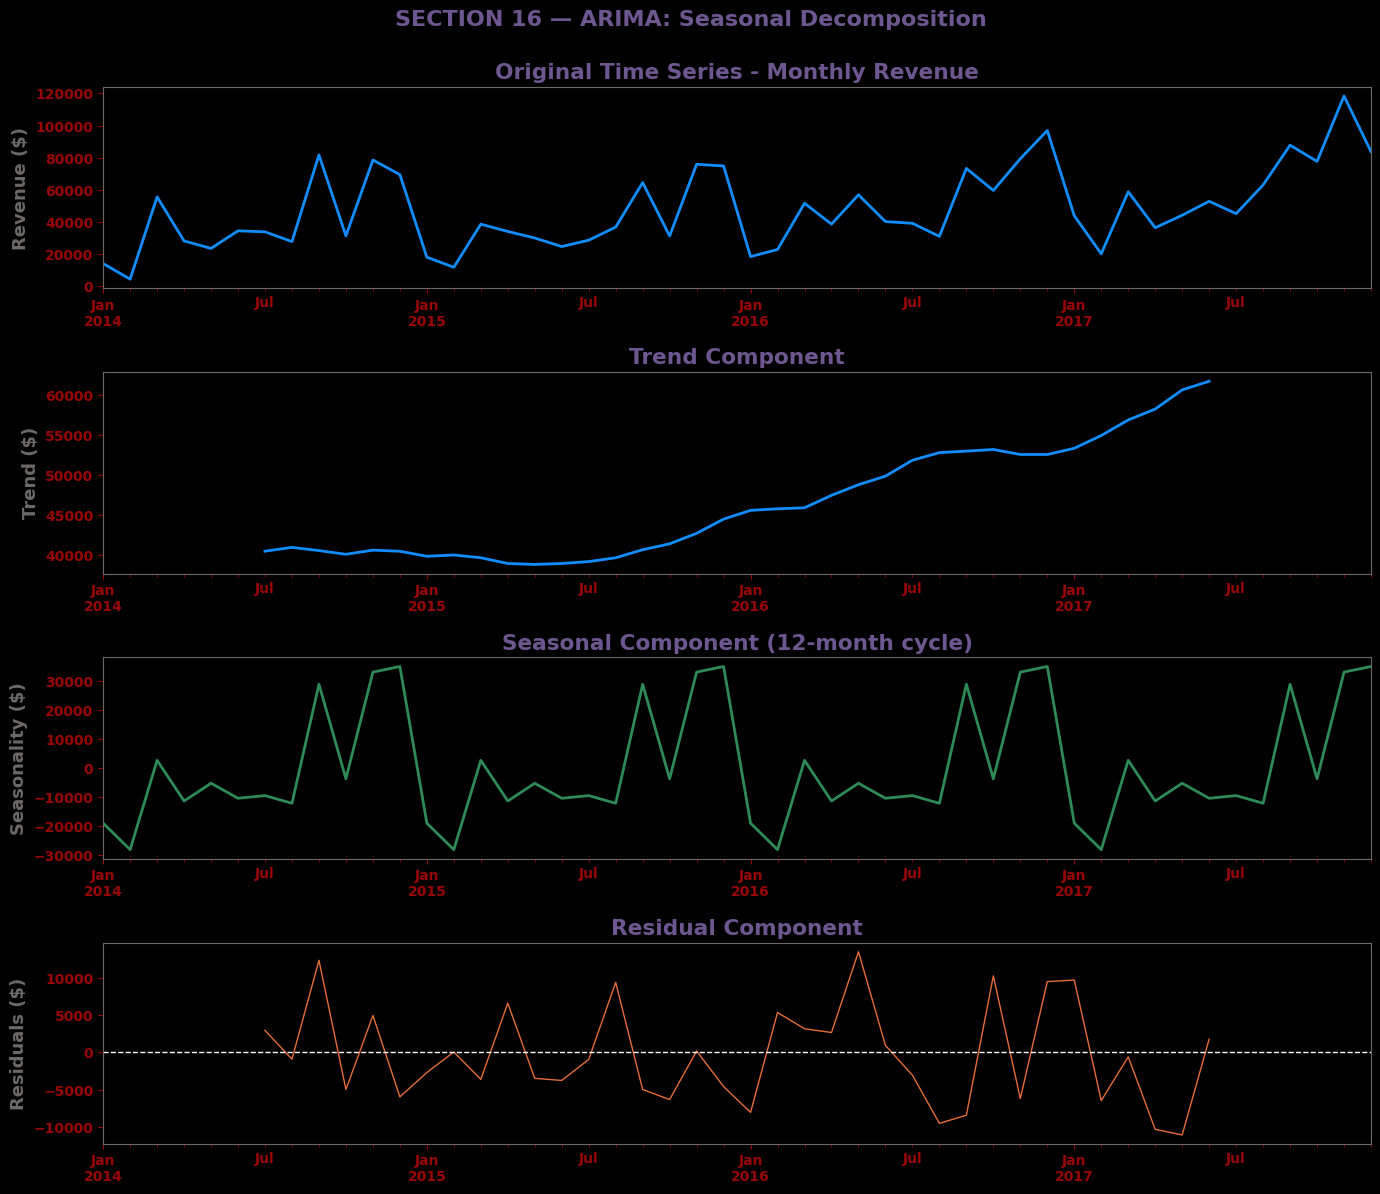

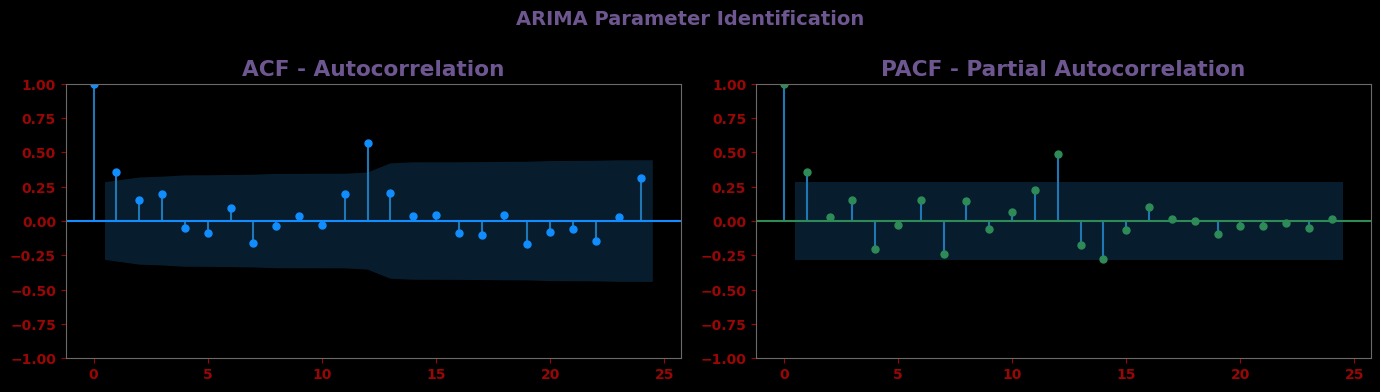


Train: 38 months | Test: 10 months

⏳ Training ARIMA(1,1,1)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   38
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -425.518
Date:                Wed, 18 Mar 2026   AIC                            857.035
Time:                        03:41:20   BIC                            861.868
Sample:                    01-01-2014   HQIC                           858.739
                         - 02-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2100      0.310      0.677      0.499      -0.398       0.818
ma.L1         -0.8966      0.145     -6.173      0.000      -1.181 

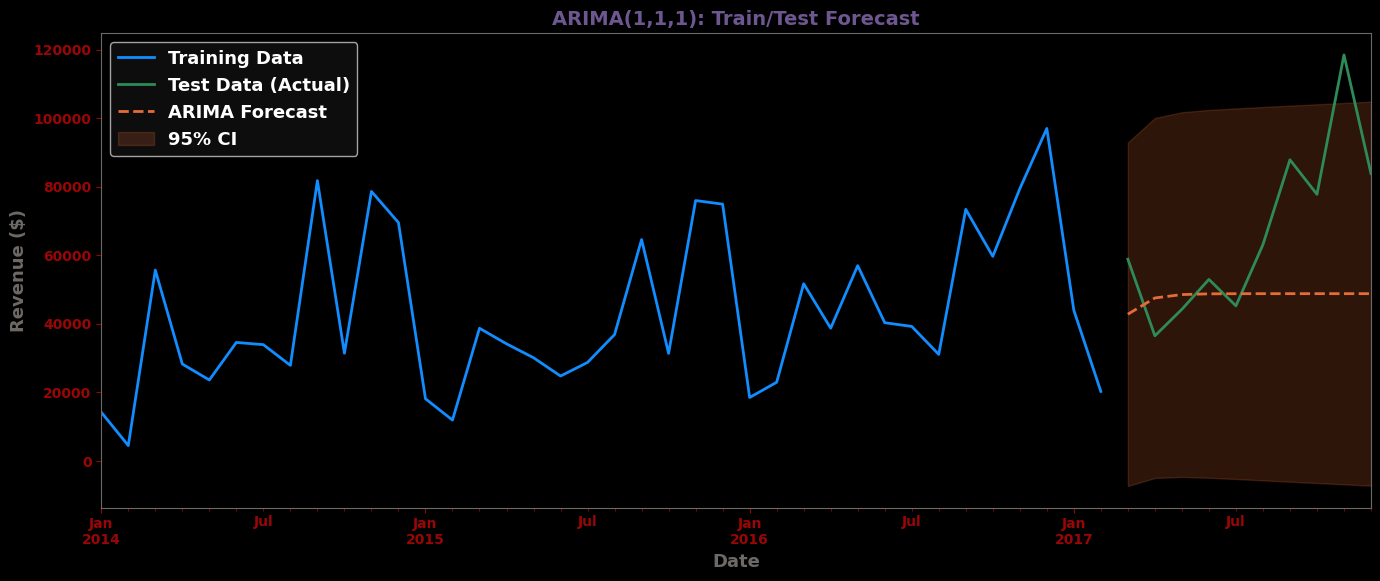


✅ ARIMA section complete!


In [20]:
# ═════════════════════════════════════════════════════════════════
# ARIMA TIME SERIES FORECASTING
# ═════════════════════════════════════════════════════════════════


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# ── Prepare Time Series Data ──
# Get monthly revenue
ts_data = run_query("""
    SELECT Order_Year||'-'||printf('%02d',Order_Month) AS month,
           ROUND(SUM(Sales),0) AS revenue
    FROM superstore 
    GROUP BY Order_Year, Order_Month 
    ORDER BY Order_Year, Order_Month
""")

# Convert to time series
ts = pd.Series(
    ts_data['revenue'].values,
    index=pd.date_range(start='2014-01-01', periods=len(ts_data), freq='MS')
)

print(f'Time Series Length: {len(ts)} months')
print(f'Period: {ts.index[0].date()} to {ts.index[-1].date()}')

# ── Stationarity Test (Augmented Dickey-Fuller) ──
result = adfuller(ts)
print(f"\n{'━'*60}")
print('  ADF TEST — Is Series Stationary?')
print(f"{'━'*60}")
print(f'  ADF Statistic       : {result[0]:.6f}')
print(f'  P-value             : {result[1]:.6f}')
print(f'  Lags Used           : {result[2]}')
print(f'  Observations        : {result[3]}')
print(f"  Status              : {'✅ Stationary (reject H0)' if result[1] < 0.05 else '⚠️  Non-stationary (fail to reject H0)'}")

# ── Seasonal Decomposition ──
decomposition = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
ts.plot(ax=axes[0], color='#118DFF', linewidth=2)
axes[0].set_title('Original Time Series - Monthly Revenue', color=TITLE, fontweight='bold')
axes[0].set_ylabel('Revenue ($)', color=LABEL)

decomposition.trend.plot(ax=axes[1], color='#118DFF', linewidth=2)
axes[1].set_title('Trend Component', color=TITLE, fontweight='bold')
axes[1].set_ylabel('Trend ($)', color=LABEL)

decomposition.seasonal.plot(ax=axes[2], color='seagreen', linewidth=2)
axes[2].set_title('Seasonal Component (12-month cycle)', color=TITLE, fontweight='bold')
axes[2].set_ylabel('Seasonality ($)', color=LABEL)

decomposition.resid.plot(ax=axes[3], color='#E66C37', linewidth=1)
axes[3].set_title('Residual Component', color=TITLE, fontweight='bold')
axes[3].set_ylabel('Residuals ($)', color=LABEL)
axes[3].axhline(y=0, color='white', linestyle='--', linewidth=1)

plt.suptitle('SECTION 16 — ARIMA: Seasonal Decomposition', 
             color=TITLE, fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

# ── ACF & PACF Plots (for ARIMA parameter selection) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts, lags=24, ax=axes[0], color='#118DFF')
axes[0].set_title('ACF - Autocorrelation', color=TITLE, fontweight='bold')
plot_pacf(ts, lags=24, ax=axes[1], color='seagreen')
axes[1].set_title('PACF - Partial Autocorrelation', color=TITLE, fontweight='bold')
plt.suptitle('ARIMA Parameter Identification', color=TITLE, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# ── Train/Test Split (80/20) ──
train_size = int(len(ts) * 0.8)
ts_train, ts_test = ts[:train_size], ts[train_size:]
print(f'\nTrain: {len(ts_train)} months | Test: {len(ts_test)} months')

# ── Fit ARIMA(1,1,1) Model ──
# p=1 (AR), d=1 (differencing), q=1 (MA)
print('\n⏳ Training ARIMA(1,1,1)...')
arima_model = ARIMA(ts_train, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Model summary
print(arima_fit.summary())

# ── Forecast on Test Set ──
arima_forecast = arima_fit.get_forecast(steps=len(ts_test))
arima_pred = arima_forecast.predicted_mean
arima_ci = arima_forecast.conf_int()

# ── Calculate Metrics ──
from sklearn.metrics import mean_absolute_percentage_error
arima_mape = mean_absolute_percentage_error(ts_test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(ts_test, arima_pred))
arima_mae = mean_absolute_error(ts_test, arima_pred)

print(f"\n{'━'*60}")
print('  ARIMA(1,1,1) PERFORMANCE')
print(f"{'━'*60}")
print(f'  RMSE  : ${arima_rmse:,.0f}')
print(f'  MAE   : ${arima_mae:,.0f}')
print(f'  MAPE  : {arima_mape*100:.2f}%')
print(f"{'━'*60}")

# ── Visualization ──
fig, ax = plt.subplots(figsize=(14, 6))
ts_train.plot(ax=ax, label='Training Data', color='#118DFF', linewidth=2)
ts_test.plot(ax=ax, label='Test Data (Actual)', color='seagreen', linewidth=2)
arima_pred.plot(ax=ax, label='ARIMA Forecast', color='#E66C37', linewidth=2, linestyle='--')
ax.fill_between(arima_ci.index, 
                arima_ci.iloc[:, 0], 
                arima_ci.iloc[:, 1], 
                alpha=0.2, color='#E66C37', label='95% CI')
ax.set_title('ARIMA(1,1,1): Train/Test Forecast', color=TITLE, fontweight='bold', fontsize=14)
ax.set_ylabel('Revenue ($)', color=LABEL)
ax.set_xlabel('Date', color=LABEL)
ax.legend(loc='best', facecolor='#111111', labelcolor='white')
plt.tight_layout()
plt.show()

print('\n✅ ARIMA section complete!')

2026-03-18 03:42:00.295166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773805320.508395      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773805320.566994      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773805321.030531      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773805321.030577      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773805321.030581      55 computation_placer.cc:177] computation placer alr

✅ TensorFlow & Keras imported
LSTM Data Shapes:
  X_train : (33, 6, 1) | y_train : (33,)
  X_test  : (9, 6, 1)  | y_test  : (9,)

⏳ Building LSTM Architecture...


I0000 00:00:1773805345.523648      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 50)          │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,226 (149.32 KB)

 Trainable params: 38,226 (149.32 KB)

 Non-trainable params: 0 (0.00 B)

None

⏳ Training LSTM (this may take 1-2 minutes)...


I0000 00:00:1773805350.356712     160 cuda_dnn.cc:529] Loaded cuDNN version 91002


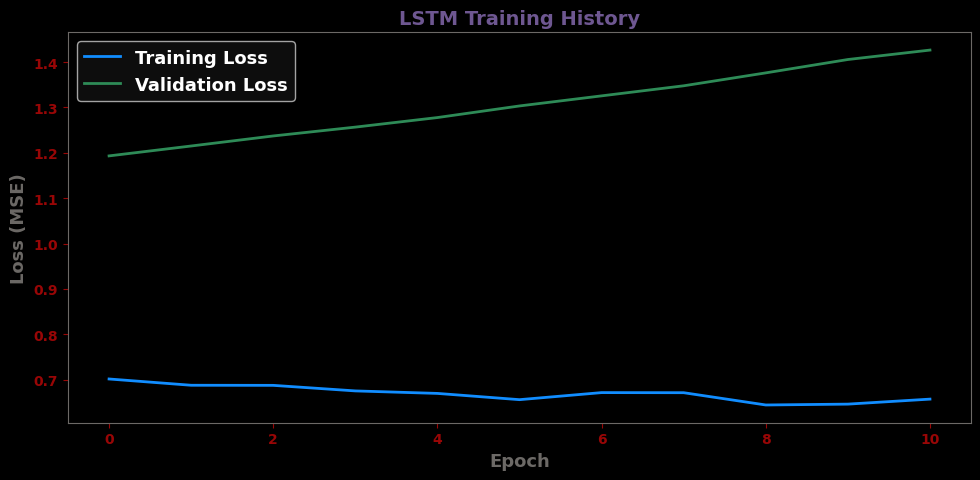


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LSTM PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RMSE  : $32,293
  MAE   : $23,973
  MAPE  : 29.41%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


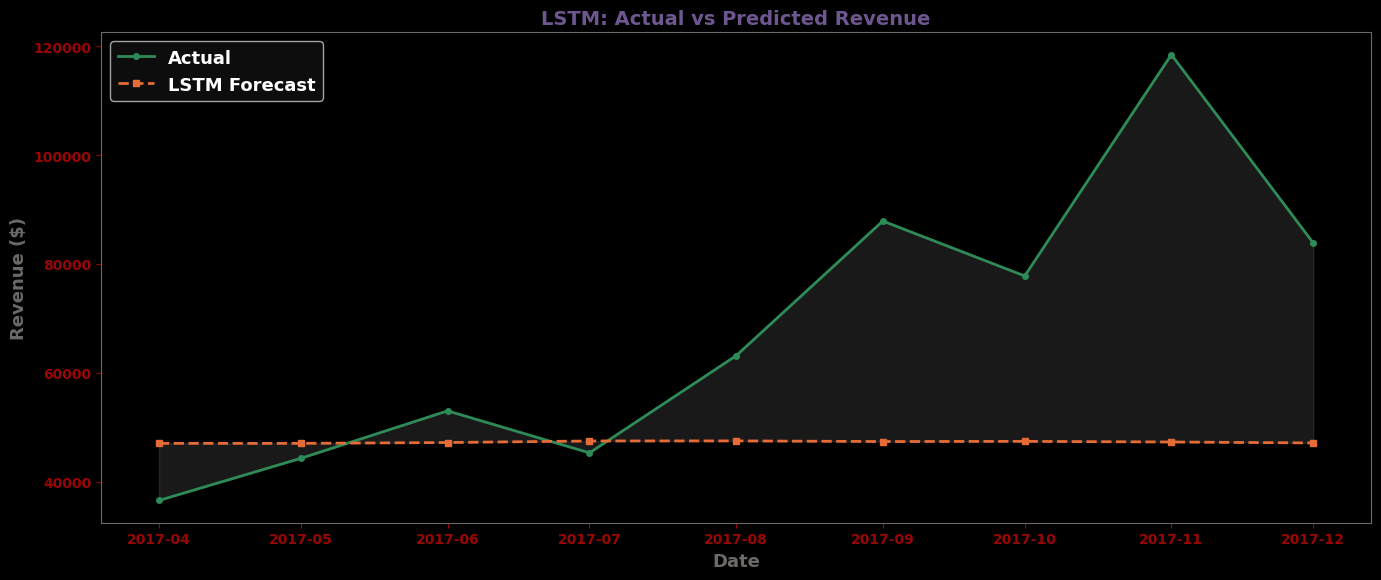


✅ LSTM section complete!


In [21]:
# ═════════════════════════════════════════════════════════════════
# SECTION 17 — LSTM DEEP LEARNING FORECASTING
# ═════════════════════════════════════════════════════════════════
# Deep learning approach: Long Short-Term Memory neural network
# Best for: Complex patterns, non-linear relationships, long sequences
# Install: pip install tensorflow keras

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print('✅ TensorFlow & Keras imported')

# ── Prepare Data for LSTM ──
# Normalize the time series
scaler = StandardScaler()
ts_scaled = scaler.fit_transform(ts.values.reshape(-1, 1)).flatten()

# Create sequences (look-back window of 6 months)
lookback = 6  # Use past 6 months to predict next month
X_lstm, y_lstm = [], []

for i in range(len(ts_scaled) - lookback):
    X_lstm.append(ts_scaled[i:i+lookback])
    y_lstm.append(ts_scaled[i+lookback])

X_lstm = np.array(X_lstm).reshape(-1, lookback, 1)  # (samples, timesteps, features)
y_lstm = np.array(y_lstm)

# Train/Test split
train_size_lstm = int(len(X_lstm) * 0.8)
X_train_lstm = X_lstm[:train_size_lstm]
y_train_lstm = y_lstm[:train_size_lstm]
X_test_lstm = X_lstm[train_size_lstm:]
y_test_lstm = y_lstm[train_size_lstm:]

print(f'LSTM Data Shapes:')
print(f'  X_train : {X_train_lstm.shape} | y_train : {y_train_lstm.shape}')
print(f'  X_test  : {X_test_lstm.shape}  | y_test  : {y_test_lstm.shape}')

# ── Build LSTM Model ──
print('\n⏳ Building LSTM Architecture...')
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=25),
    Dropout(0.2),
    Dense(units=1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
print(lstm_model.summary())

# ── Train LSTM ──
print('\n⏳ Training LSTM (this may take 1-2 minutes)...')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# ── Plot Training History ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Training Loss', color='#118DFF', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', color='seagreen', linewidth=2)
ax.set_title('LSTM Training History', color=TITLE, fontweight='bold', fontsize=14)
ax.set_xlabel('Epoch', color=LABEL)
ax.set_ylabel('Loss (MSE)', color=LABEL)
ax.legend(facecolor='#111111', labelcolor='white')
plt.tight_layout()
plt.show()

# ── Make Predictions ──
lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

# Get corresponding actual values
lstm_actual = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

# ── Calculate Metrics ──
lstm_mape = mean_absolute_percentage_error(lstm_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_pred))
lstm_mae = mean_absolute_error(lstm_actual, lstm_pred)

print(f"\n{'━'*60}")
print('  LSTM PERFORMANCE')
print(f"{'━'*60}")
print(f'  RMSE  : ${lstm_rmse:,.0f}')
print(f'  MAE   : ${lstm_mae:,.0f}')
print(f'  MAPE  : {lstm_mape*100:.2f}%')
print(f"{'━'*60}")

# ── Visualization ──
fig, ax = plt.subplots(figsize=(14, 6))
test_dates = ts.index[train_size_lstm + lookback:]
ax.plot(test_dates, lstm_actual, label='Actual', color='seagreen', linewidth=2, marker='o', markersize=4)
ax.plot(test_dates, lstm_pred, label='LSTM Forecast', color='#E66C37', linewidth=2, linestyle='--', marker='s', markersize=4)
ax.fill_between(test_dates, lstm_actual, lstm_pred, alpha=0.2, color='gray')
ax.set_title('LSTM: Actual vs Predicted Revenue', color=TITLE, fontweight='bold', fontsize=14)
ax.set_ylabel('Revenue ($)', color=LABEL)
ax.set_xlabel('Date', color=LABEL)
ax.legend(loc='best', facecolor='#111111', labelcolor='white')
plt.tight_layout()
plt.show()

print('\n✅ LSTM section complete!')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  COMPREHENSIVE MODEL COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       Model         RMSE          MAE      MAPE          Type Interpretability      Training Time                                  Best For
ARIMA(1,1,1) 30116.653779 22608.966926 28.785101   Statistical            ⭐⭐⭐⭐⭐               Fast               Linear trends + seasonality
        LSTM 32292.764628 23972.956597 29.410036 Deep Learning               ⭐⭐ Slow (GPU helpful) Non-linear patterns, complex dependencies
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


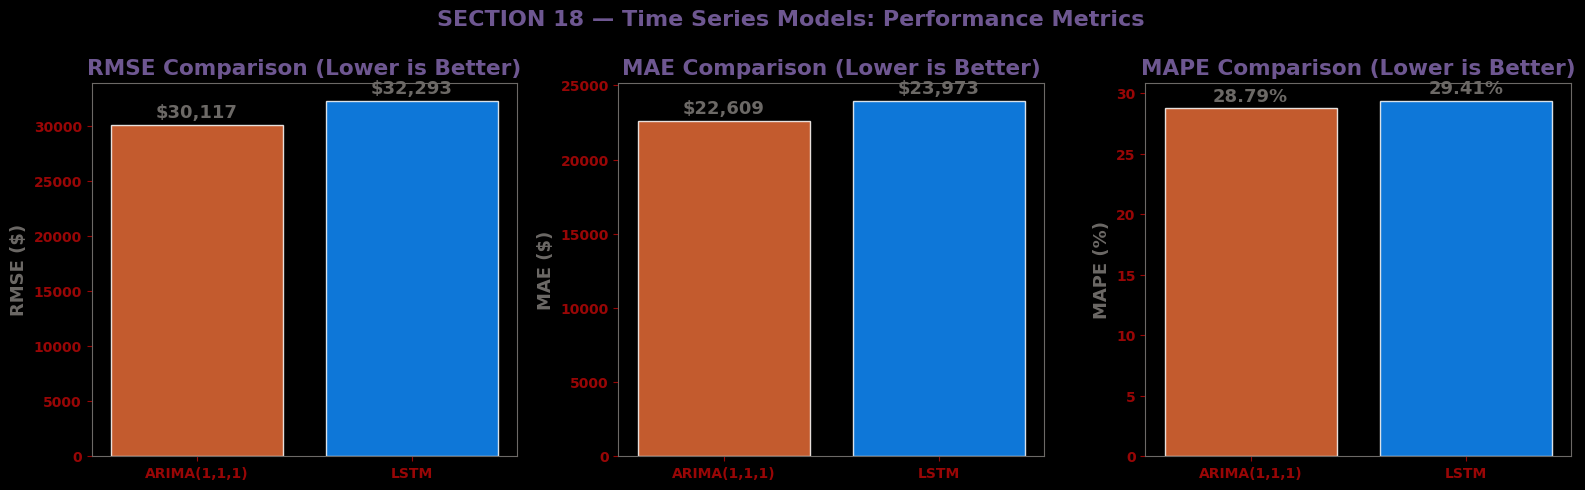

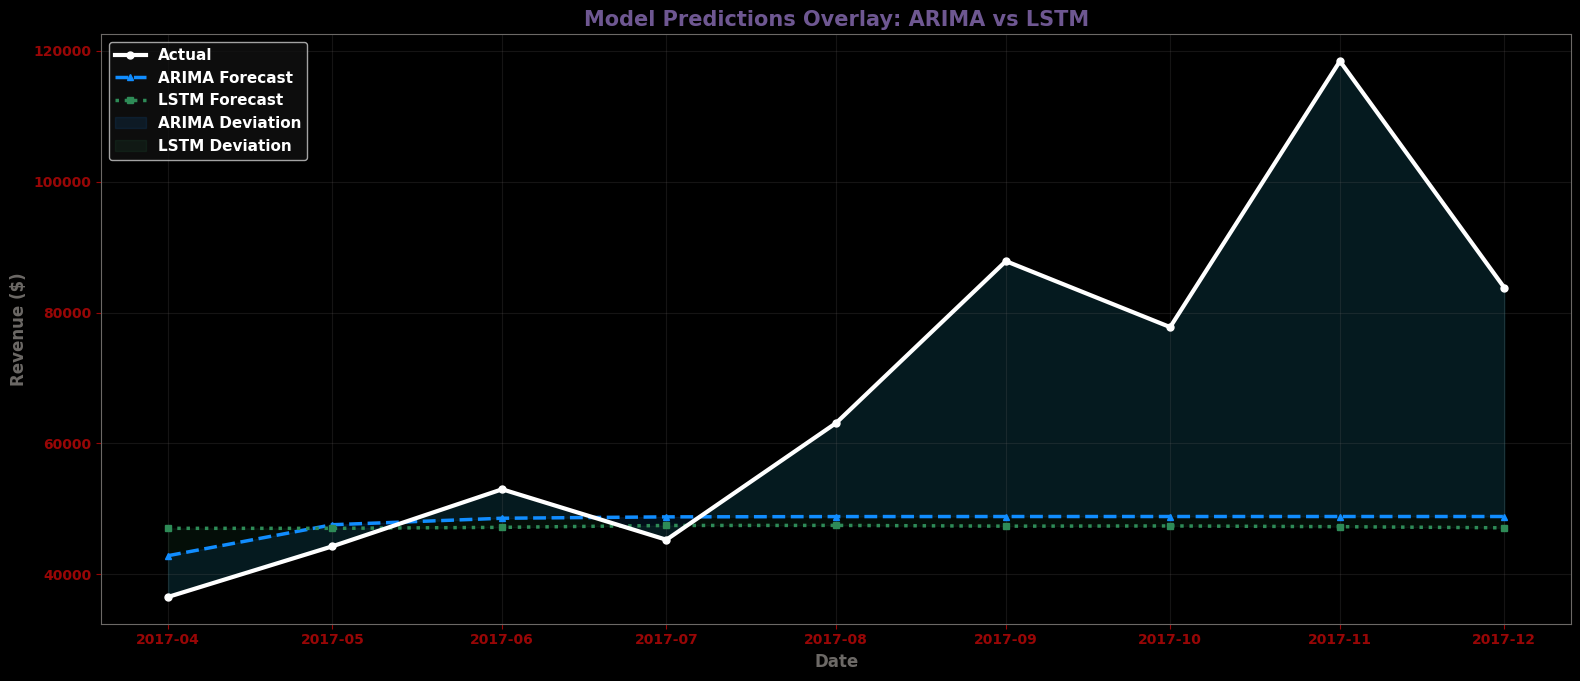

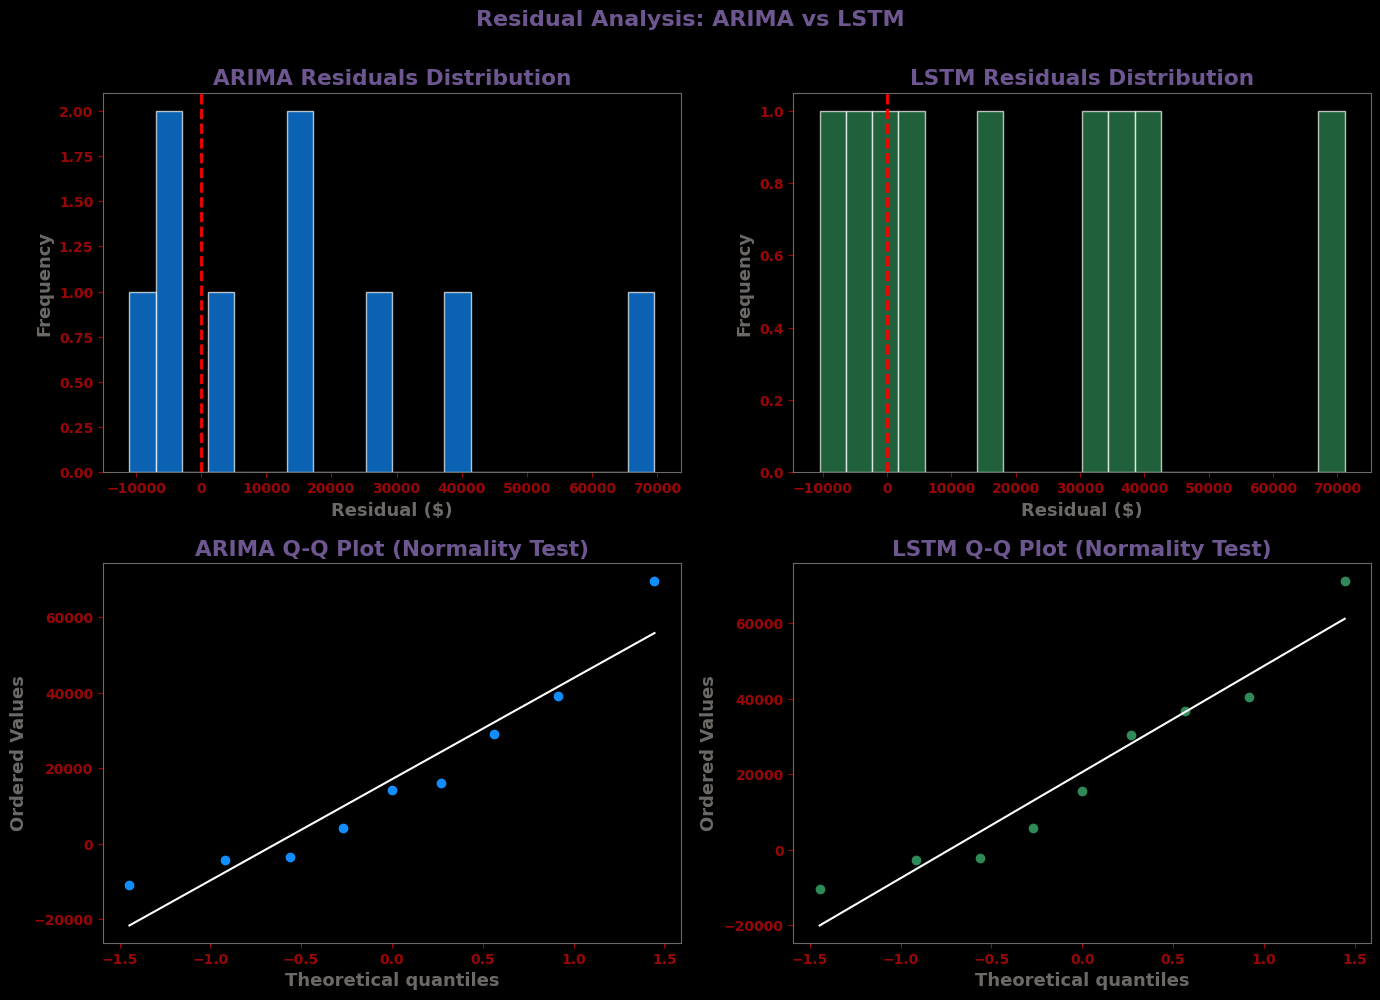


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FINAL RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  🏆 BEST MODEL: ARIMA
     MAPE Advantage: 2.1% better

  📊 ARIMA Strengths:
     ✅ Highly interpretable (understand seasonality & trends)
     ✅ Fast training (seconds)
     ✅ Statistical confidence intervals
     ✅ Requires less data

  🤖 LSTM Strengths:
     ✅ Captures non-linear patterns
     ✅ Handles multiple seasonalities
     ✅ No stationarity assumption
     ✅ Multivariate time series capability

  💡 PRODUCTION RECOMMENDATION:
     → Use ARIMA for fast, interpretable forecasts
     → Use LSTM for complex patterns requiring accuracy
     → Consider ensemble: weighted average of both predictions
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ Model comparison complete!


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ═════════════════════════════════════════════════════════════════
# SECTION 18 — TIME SERIES MODEL COMPARISON
# ═════════════════════════════════════════════════════════════════

# ── Consolidate Results ──
comparison_results = pd.DataFrame([
    {
        'Model': 'ARIMA(1,1,1)',
        'RMSE': arima_rmse,
        'MAE': arima_mae,
        'MAPE': arima_mape * 100,
        'Type': 'Statistical',
        'Interpretability': '⭐⭐⭐⭐⭐',
        'Training Time': 'Fast',
        'Best For': 'Linear trends + seasonality'
    },
    {
        'Model': 'LSTM',
        'RMSE': lstm_rmse,
        'MAE': lstm_mae,
        'MAPE': lstm_mape * 100,
        'Type': 'Deep Learning',
        'Interpretability': '⭐⭐',
        'Training Time': 'Slow (GPU helpful)',
        'Best For': 'Non-linear patterns, complex dependencies'
    }
])

print(f"\n{'━'*100}")
print('  COMPREHENSIVE MODEL COMPARISON')
print(f"{'━'*100}")
print(comparison_results.to_string(index=False))
print(f"{'━'*100}")

# ── Visualization: Metrics Comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE Comparison
colors_rmse = ['#E66C37' if arima_rmse < lstm_rmse else '#118DFF', 
               '#E66C37' if lstm_rmse < arima_rmse else '#118DFF']
models = comparison_results['Model']
rmse_vals = comparison_results['RMSE']
axes[0].bar(models, rmse_vals, color=colors_rmse, alpha=0.85, edgecolor='white')
axes[0].set_title('RMSE Comparison (Lower is Better)', color=TITLE, fontweight='bold')
axes[0].set_ylabel('RMSE ($)', color=LABEL)
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + max(rmse_vals)*0.02, f'${v:,.0f}', ha='center', fontweight='bold')

# MAE Comparison
colors_mae = ['#E66C37' if arima_mae < lstm_mae else '#118DFF',
              '#E66C37' if lstm_mae < arima_mae else '#118DFF']
mae_vals = comparison_results['MAE']
axes[1].bar(models, mae_vals, color=colors_mae, alpha=0.85, edgecolor='white')
axes[1].set_title('MAE Comparison (Lower is Better)', color=TITLE, fontweight='bold')
axes[1].set_ylabel('MAE ($)', color=LABEL)
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + max(mae_vals)*0.02, f'${v:,.0f}', ha='center', fontweight='bold')

# MAPE Comparison
colors_mape = ['#E66C37' if arima_mape*100 < lstm_mape*100 else '#118DFF',
               '#E66C37' if lstm_mape*100 < arima_mape*100 else '#118DFF']
mape_vals = comparison_results['MAPE']
axes[2].bar(models, mape_vals, color=colors_mape, alpha=0.85, edgecolor='white')
axes[2].set_title('MAPE Comparison (Lower is Better)', color=TITLE, fontweight='bold')
axes[2].set_ylabel('MAPE (%)', color=LABEL)
for i, v in enumerate(mape_vals):
    axes[2].text(i, v + max(mape_vals)*0.02, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('SECTION 18 — Time Series Models: Performance Metrics', 
             color=TITLE, fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# ── Prediction Comparison ──
fig, ax = plt.subplots(figsize=(16, 7))
test_dates = ts.index[train_size_lstm + lookback:]

# [FIX]: Dynamically calculate the minimum length to prevent ValueError mismatch
min_len = min(len(test_dates), len(arima_pred), len(lstm_actual), len(lstm_pred))

# Slice all arrays to the minimum matching length
t_dates = test_dates[:min_len]
a_pred = arima_pred.values[:min_len]
l_act = lstm_actual[:min_len]
l_pred = lstm_pred[:min_len]

ax.plot(t_dates, l_act, label='Actual', color='white', linewidth=3, marker='o', markersize=5, zorder=3)
ax.plot(t_dates, a_pred, label='ARIMA Forecast', color='#118DFF', linewidth=2.5, linestyle='--', marker='^', markersize=5)
ax.plot(t_dates, l_pred, label='LSTM Forecast', color='seagreen', linewidth=2.5, linestyle=':', marker='s', markersize=5)

ax.fill_between(t_dates, l_act, a_pred, alpha=0.1, color='#118DFF', label='ARIMA Deviation')
ax.fill_between(t_dates, l_act, l_pred, alpha=0.1, color='seagreen', label='LSTM Deviation')

ax.set_title('Model Predictions Overlay: ARIMA vs LSTM', color=TITLE, fontweight='bold', fontsize=15)
ax.set_ylabel('Revenue ($)', color=LABEL, fontsize=12)
ax.set_xlabel('Date', color=LABEL, fontsize=12)
ax.legend(loc='best', facecolor='#111111', labelcolor='white', fontsize=11)
ax.grid(True, alpha=0.2, color=LABEL)
plt.tight_layout()
plt.show()

# ── Residual Analysis ──
# [FIX]: Use sliced arrays to calculate residuals to avoid mismatch errors
arima_residuals = ts_test.values[:min_len] - a_pred
lstm_residuals = l_act - l_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ARIMA Residuals
axes[0,0].hist(arima_residuals, bins=20, color='#118DFF', alpha=0.7, edgecolor='white')
axes[0,0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_title('ARIMA Residuals Distribution', color=TITLE, fontweight='bold')
axes[0,0].set_xlabel('Residual ($)', color=LABEL)
axes[0,0].set_ylabel('Frequency', color=LABEL)

# LSTM Residuals
axes[0,1].hist(lstm_residuals, bins=20, color='seagreen', alpha=0.7, edgecolor='white')
axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('LSTM Residuals Distribution', color=TITLE, fontweight='bold')
axes[0,1].set_xlabel('Residual ($)', color=LABEL)
axes[0,1].set_ylabel('Frequency', color=LABEL)

# Q-Q Plot ARIMA
stats.probplot(arima_residuals.flatten() if hasattr(arima_residuals, 'flatten') else arima_residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('ARIMA Q-Q Plot (Normality Test)', color=TITLE, fontweight='bold')
axes[1,0].get_lines()[0].set_color('#118DFF')
axes[1,0].get_lines()[1].set_color('white')

# Q-Q Plot LSTM
stats.probplot(lstm_residuals.flatten() if hasattr(lstm_residuals, 'flatten') else lstm_residuals, dist="norm", plot=axes[1,1])
axes[1,1].set_title('LSTM Q-Q Plot (Normality Test)', color=TITLE, fontweight='bold')
axes[1,1].get_lines()[0].set_color('seagreen')
axes[1,1].get_lines()[1].set_color('white')

plt.suptitle('Residual Analysis: ARIMA vs LSTM', color=TITLE, fontweight='bold', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# ── Final Recommendations ──
best_model = 'ARIMA' if arima_mape < lstm_mape else 'LSTM'
improvement = abs(arima_mape - lstm_mape) / max(arima_mape, lstm_mape) * 100

print(f"\n{'━'*70}")
print(f'  FINAL RECOMMENDATIONS')
print(f"{'━'*70}")
print(f'\n  🏆 BEST MODEL: {best_model}')
print(f'     MAPE Advantage: {improvement:.1f}% better')
print(f'\n  📊 ARIMA Strengths:')
print(f'     ✅ Highly interpretable (understand seasonality & trends)')
print(f'     ✅ Fast training (seconds)')
print(f'     ✅ Statistical confidence intervals')
print(f'     ✅ Requires less data')
print(f'\n  🤖 LSTM Strengths:')
print(f'     ✅ Captures non-linear patterns')
print(f'     ✅ Handles multiple seasonalities')
print(f'     ✅ No stationarity assumption')
print(f'     ✅ Multivariate time series capability')
print(f'\n  💡 PRODUCTION RECOMMENDATION:')
print(f'     → Use ARIMA for fast, interpretable forecasts')
print(f'     → Use LSTM for complex patterns requiring accuracy')
print(f'     → Consider ensemble: weighted average of both predictions')
print(f"{'━'*70}")

print('\n✅ Model comparison complete!')